### Run the Streamlit dashboard (optional)
Run the cell below to install dependencies and start the dashboard. Then open **http://localhost:8501** in your browser.

In [ ]:
# Use the same Python as this notebook (avoids "python/pip/streamlit not found" in shell)
import sys
import subprocess
import os

project_dir = r"c:\Users\uwtuser\OneDrive - UW\Desktop\Portfolio Project\AI Powered Data Analysis"
os.chdir(project_dir)
python = sys.executable

# Install dependencies (quiet)
subprocess.run([python, "-m", "pip", "install", "-q", "pandas", "openpyxl", "streamlit", "plotly", "numpy"], check=False)
# Start dashboard in background so this cell can finish
subprocess.Popen([python, "-m", "streamlit", "run", "dashboard.py", "--server.port", "8501"], cwd=project_dir)
print("Dashboard starting. Open in browser: http://localhost:8501")

# RFM Analysis — Online Retail

Customer segmentation using Recency, Frequency, and Monetary value.

## What is RFM analysis?

**RFM** stands for **Recency**, **Frequency**, and **Monetary value** — three behavioural metrics derived from transaction history:

- **Recency:** How recently did the customer last purchase? (e.g. days since last order.)
- **Frequency:** How often do they buy? (e.g. number of orders in the analysis period.)
- **Monetary:** How much do they spend? (e.g. total revenue from that customer.)

Customers are scored on each dimension (e.g. 1–5), then combined into segments (e.g. Champions = high on all three; At Risk = low recency but high frequency/monetary).

## How it adds value for e-commerce

- **Prioritise actions:** Identify who to retain (e.g. At Risk), reward (Champions), re-engage (Lost), or grow (e.g. new or potential loyal).
- **Personalise messaging:** Different email and on-site campaigns by segment (e.g. win-back vs loyalty offers).
- **Improve retention and LTV:** Focus retention efforts on high-value customers who are slipping (low recency, high F/M).
- **Budget and forecasting:** Understand how much revenue sits in each segment and how many customers are in each bucket.

## What we can learn from this dataset

- **Segment sizes and revenue concentration:** How many customers fall into Champions vs At Risk vs Lost, and where most revenue comes from.
- **Retention and churn signals:** Which customers have not bought recently but used to buy often — prime targets for win-back.
- **Best and worst customer health:** Who are the most valuable, frequent, and recent (Champions) vs those at risk or already lost.
- **Actionable lists:** Exportable segments for marketing (e.g. CustomerID lists for email campaigns) and for prioritising product and pricing strategies.

## 1. Load and prepare data

Load the dataset and apply the same cleaning as in the main analysis so we have valid orders with Revenue and CustomerID.

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

df = pd.read_excel("Online Retail.xlsx")

# Same cleaning as main notebook: drop duplicates, drop missing CustomerID/Description, exclude cancellations and invalid qty/price
clean = df.drop_duplicates()
clean = clean.dropna(subset=["CustomerID", "Description", "InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice", "Country"])
inv = clean["InvoiceNo"].astype(str)
clean = clean.loc[~inv.str.startswith("C", na=False)]
clean = clean.loc[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]
clean["Revenue"] = clean["Quantity"] * clean["UnitPrice"]
clean["CustomerID"] = clean["CustomerID"].astype(int)

print(f"Cleaned data: {len(clean):,} rows, {clean['InvoiceNo'].nunique():,} orders, {clean['CustomerID'].nunique():,} customers")
clean.head(5)

Cleaned data: 392,692 rows, 18,532 orders, 4,338 customers


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Compute RFM metrics (customer-level)

Reference date = day after the last invoice in the data. For each customer we compute:
- **Recency:** days between last order and reference date.
- **Frequency:** number of distinct orders.
- **Monetary:** sum of Revenue.

In [11]:
ref_date = clean["InvoiceDate"].max() + timedelta(days=1)

rfm = clean.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

print(f"Reference date for Recency: {ref_date.date()}")
print(f"Customers with at least one order: {len(rfm):,}")
rfm.describe()

Reference date for Recency: 2011-12-10
Customers with at least one order: 4,338


,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


## 3. Score RFM (quartiles 1–4)

Recency: lower is better → rank so that **smaller recency = higher score**.
Frequency and Monetary: higher is better → **higher = higher score**.

We use quartiles (1–4) and label 4 as best; then combine into an RFM segment string.

In [12]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1], duplicates="drop")
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4], duplicates="drop")
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=4, labels=[1, 2, 3, 4], duplicates="drop")

rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

rfm["RFM_Segment"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,12346,326,1,77183.60,1,1,4,114
1,12347,2,7,4310.00,4,4,4,444
2,12348,75,4,1797.24,2,3,4,234
3,12349,19,1,1757.55,3,1,4,314
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,4,4,344
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,3,113
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,3,3,4,334


## 4. Label named segments

Map RFM scores to common segment names for easier interpretation and action.

In [13]:
def rfm_segment_name(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 3 and m >= 3:
        return "Champions"
    if r >= 3 and f >= 2 and m >= 2:
        return "Loyal"
    if r >= 3 and (f <= 2 or m <= 2):
        return "Potential loyal"
    if r == 2 and f >= 2 and m >= 2:
        return "At risk"
    if r <= 2 and f >= 3 and m >= 3:
        return "Can't lose"
    if r <= 2 and f <= 2 and m >= 2:
        return "Hibernating"
    if r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    if r >= 3 and f <= 1 and m <= 1:
        return "New"
    if r <= 1:
        return "Lost"
    return "Other"

rfm["Segment"] = rfm.apply(rfm_segment_name, axis=1)
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment
0,12346,326,1,77183.60,1,1,4,114,Hibernating
1,12347,2,7,4310.00,4,4,4,444,Champions
2,12348,75,4,1797.24,2,3,4,234,At risk
3,12349,19,1,1757.55,3,1,4,314,Potential loyal
4,12350,310,1,334.40,1,1,2,112,Hibernating
5,12352,36,8,2506.04,3,4,4,344,Loyal
6,12353,204,1,89.00,1,1,1,111,Lost
7,12354,232,1,1079.40,1,1,3,113,Hibernating
8,12355,214,1,459.40,1,1,2,112,Hibernating
9,12356,23,3,2811.43,3,3,4,334,Loyal


## 5. Segment summary (count and revenue)

In [14]:
seg_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Monetary", "sum"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
).reset_index()

total_rev = rfm["Monetary"].sum()
seg_summary["RevenueSharePct"] = (seg_summary["Total_Revenue"] / total_rev * 100).round(2)
seg_summary = seg_summary.sort_values("Total_Revenue", ascending=False).reset_index(drop=True)

print("Segment summary (customers and revenue)")
display(seg_summary.style.format({
    "Total_Revenue": "£{:,.2f}",
    "Avg_Recency": "{:.1f}",
    "Avg_Frequency": "{:.2f}",
    "Avg_Monetary": "£{:,.2f}",
    "RevenueSharePct": "{:.1f}%",
}))

Segment summary (customers and revenue)


,Segment,Customers,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Monetary,RevenueSharePct
0,Champions,797,"£4,897,939.91",8.0,11.32,"£6,145.47",55.1%
1,Loyal,962,"£2,060,795.48",27.4,4.54,"£2,142.20",23.2%
2,At risk,649,"£931,892.70",83.9,3.60,"£1,435.89",10.5%
3,Hibernating,577,"£472,647.72",200.3,1.25,£819.15,5.3%
4,Can't lose,89,"£234,479.09",201.5,4.53,"£2,634.60",2.6%
5,Lost,816,"£160,664.85",205.7,1.31,£196.89,1.8%
6,Potential loyal,429,"£124,999.08",25.8,1.31,£291.37,1.4%
7,Other,19,"£3,790.06",90.8,2.53,£199.48,0.0%


## 5b. Priority Matrix

Segment-level **priority** and **recommended action** for marketing and retention. The matrix below maps Recency score (rows) vs Monetary score (columns); colour indicates priority (red = act first, green = retain/reward).

Priority Matrix (by segment)


,Segment,Priority,Recommended action,Customers,Total_Revenue,RevenueSharePct
0,Champions,P1 – High,Retain & reward,797,"£4,897,939.91",55.1%
1,Loyal,P1 – High,Retain,962,"£2,060,795.48",23.2%
2,At risk,P1 – High,Win-back urgently,649,"£931,892.70",10.5%
3,Hibernating,P2 – Medium,Re-engage,577,"£472,647.72",5.3%
4,Can't lose,P1 – High,Win-back urgently,89,"£234,479.09",2.6%
5,Lost,P3 – Lower,Low-cost re-engage,816,"£160,664.85",1.8%
6,Potential loyal,P2 – Medium,Nurture,429,"£124,999.08",1.4%
7,Other,P3 – Lower,Review,19,"£3,790.06",0.0%


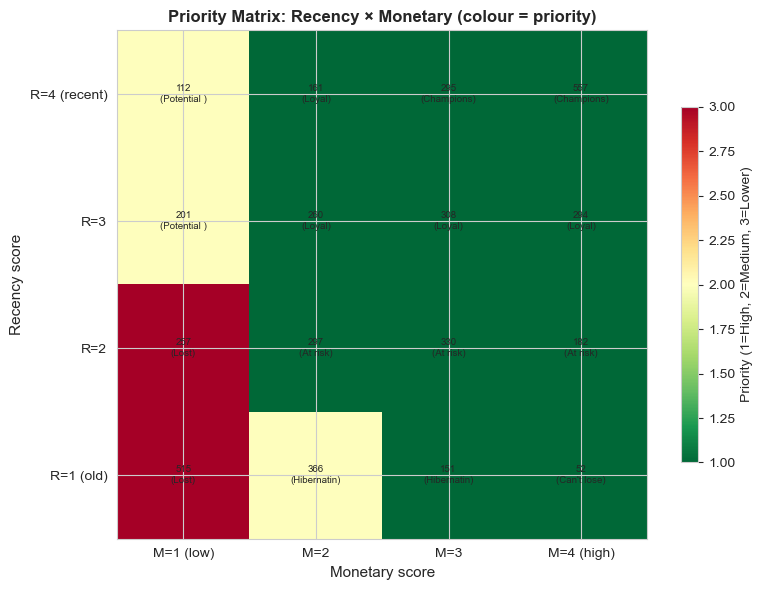

In [15]:
# Segment → Priority and recommended action
priority_action = {
    "Champions":     ("P1 – High", "Retain & reward"),
    "Loyal":         ("P1 – High", "Retain"),
    "At risk":       ("P1 – High", "Win-back urgently"),
    "Can't lose":    ("P1 – High", "Win-back urgently"),
    "Hibernating":   ("P2 – Medium", "Re-engage"),
    "Potential loyal": ("P2 – Medium", "Nurture"),
    "Lost":          ("P3 – Lower", "Low-cost re-engage"),
    "Other":         ("P3 – Lower", "Review"),
}
priority_df = seg_summary[["Segment", "Customers", "Total_Revenue", "RevenueSharePct"]].copy()
priority_df["Priority"] = priority_df["Segment"].map(lambda s: priority_action.get(s, ("—", "—"))[0])
priority_df["Recommended action"] = priority_df["Segment"].map(lambda s: priority_action.get(s, ("—", "—"))[1])
priority_df = priority_df[["Segment", "Priority", "Recommended action", "Customers", "Total_Revenue", "RevenueSharePct"]]
print("Priority Matrix (by segment)")
display(priority_df.style.format({"Total_Revenue": "£{:,.2f}", "RevenueSharePct": "{:.1f}%"}))

# R_Score x M_Score priority matrix (priority level 1=high, 2=medium, 3=low)
priority_level = {"Champions": 1, "Loyal": 1, "At risk": 1, "Can't lose": 1,
                  "Hibernating": 2, "Potential loyal": 2, "Lost": 3, "Other": 3}
rfm["PriorityLevel"] = rfm["Segment"].map(priority_level).fillna(3).astype(int)
matrix = rfm.groupby(["R_Score", "M_Score"]).agg(
    Customers=("CustomerID", "count"),
    DominantSegment=("Segment", lambda x: x.mode().iloc[0] if len(x) else ""),
    PriorityLevel=("PriorityLevel", "min"),
).reset_index()

# Pivot for heatmap: rows = R_Score (4=best recency), cols = M_Score (4=best monetary)
pivot_priority = matrix.pivot(index="R_Score", columns="M_Score", values="PriorityLevel").fillna(2)
pivot_customers = matrix.pivot(index="R_Score", columns="M_Score", values="Customers").fillna(0).astype(int)
pivot_segment = matrix.pivot(index="R_Score", columns="M_Score", values="DominantSegment")

# Plot: R_Score 4 at top (most recent), M_Score 4 at right (highest value)
idx_order = [4, 3, 2, 1]
col_order = [1, 2, 3, 4]
pivot_priority = pivot_priority.reindex(index=idx_order, columns=col_order).fillna(2)
pivot_customers = pivot_customers.reindex(index=idx_order, columns=col_order).fillna(0).astype(int)
pivot_segment = pivot_segment.reindex(index=idx_order, columns=col_order)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_priority.values, cmap="RdYlGn_r", vmin=1, vmax=3, aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["M=1 (low)", "M=2", "M=3", "M=4 (high)"])
ax.set_yticks(range(4))
ax.set_yticklabels(["R=4 (recent)", "R=3", "R=2", "R=1 (old)"])
ax.set_xlabel("Monetary score", fontsize=11)
ax.set_ylabel("Recency score", fontsize=11)
ax.set_title("Priority Matrix: Recency × Monetary (colour = priority)", fontsize=12, fontweight="bold")
for i in range(4):
    for j in range(4):
        n = int(pivot_customers.iloc[i, j]) if i < len(pivot_customers) and j < pivot_customers.shape[1] else 0
        seg = pivot_segment.iloc[i, j]
        seg_str = (str(seg)[:10] if pd.notna(seg) and seg else "") or ""
        text = f"{n}\n({seg_str})" if seg_str else str(n)
        ax.text(j, i, text, ha="center", va="center", fontsize=7)
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("Priority (1=High, 2=Medium, 3=Lower)")
plt.tight_layout()
plt.show()

## 6. Visualisations

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

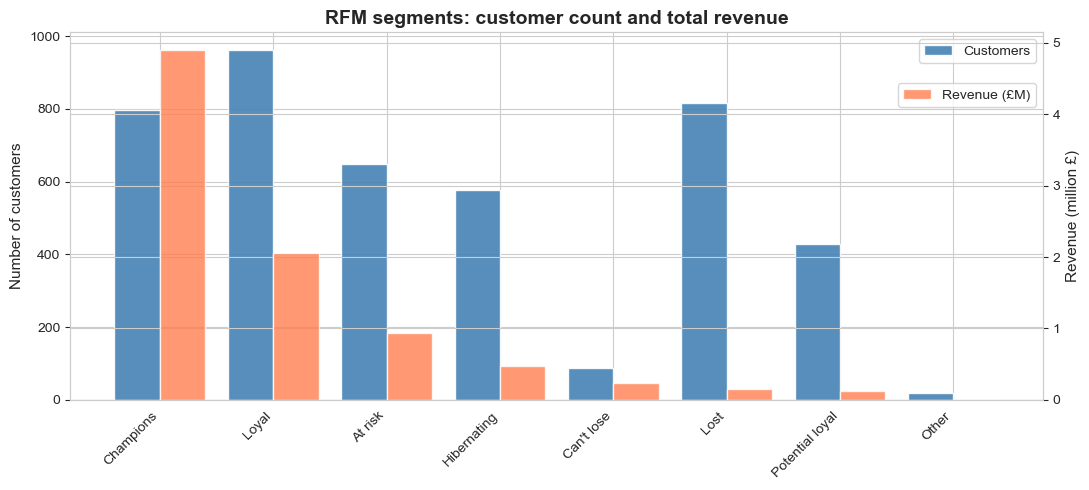

In [17]:
# Customers and revenue by segment (bar)
fig, ax1 = plt.subplots(figsize=(11, 5))
x = range(len(seg_summary))
ax1.bar([i - 0.2 for i in x], seg_summary["Customers"], width=0.4, label="Customers", color="steelblue", alpha=0.9)
ax1.set_ylabel("Number of customers", fontsize=11)
ax1.legend(loc="upper right")

ax2 = ax1.twinx()
ax2.bar([i + 0.2 for i in x], seg_summary["Total_Revenue"] / 1e6, width=0.4, label="Revenue (£M)", color="coral", alpha=0.8)
ax2.set_ylabel("Revenue (million £)", fontsize=11)
ax2.legend(loc="upper right", bbox_to_anchor=(1, 0.88))

ax1.set_xticks(x)
ax1.set_xticklabels(seg_summary["Segment"], rotation=45, ha="right")
ax1.set_title("RFM segments: customer count and total revenue", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

C:\Users\uwtuser\AppData\Local\Temp\ipykernel_34500\2826049473.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=seg_color[s], label=s, s=50) for s in seg_order]


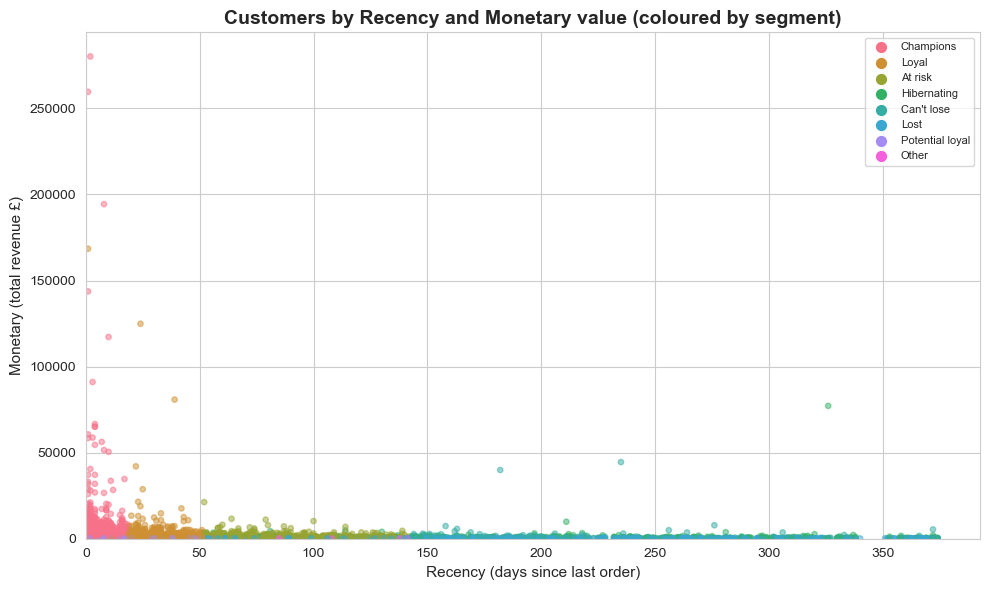

In [18]:
# Recency vs Monetary (scatter, coloured by Segment)
seg_order = seg_summary["Segment"].tolist()
pal = sns.color_palette("husl", n_colors=len(seg_order))
seg_color = {s: pal[i] for i, s in enumerate(seg_order)}
colors = rfm["Segment"].map(seg_color)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rfm["Recency"], rfm["Monetary"], c=colors, alpha=0.5, s=15)
ax.set_xlabel("Recency (days since last order)", fontsize=11)
ax.set_ylabel("Monetary (total revenue £)", fontsize=11)
ax.set_title("Customers by Recency and Monetary value (coloured by segment)", fontsize=14, fontweight="bold")
ax.set_ylim(bottom=0)
ax.set_xlim(left=0)
handles = [plt.scatter([], [], c=seg_color[s], label=s, s=50) for s in seg_order]
ax.legend(handles=handles, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Export segments (optional)

Uncomment and run to save customer IDs by segment for use in campaigns.

In [20]:
# for seg in rfm["Segment"].unique():
#     rfm[rfm["Segment"] == seg][["CustomerID", "Recency", "Frequency", "Monetary", "Segment"]].to_csv(f"rfm_{seg.replace(' ', '_')}.csv", index=False)
print("Segment columns available for export:", list(rfm.columns))
rfm["Segment"].value_counts()

Segment columns available for export: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Segment', 'Segment', 'PriorityLevel']


Segment
Loyal              962
Lost               816
Champions          797
At risk            649
Hibernating        577
Potential loyal    429
Can't lose          89
Other               19
Name: count, dtype: int64

In [22]:
cd "c:\Users\uwtuser\OneDrive - UW\Desktop\Portfolio Project\AI Powered Data Analysis"
pip install pandas openpyxl streamlit plotly numpy
streamlit run dashboard.py --server.port 8501

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (278874204.py, line 1)